In [11]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [12]:
import src.dataset as dataset
import src.models as models
import matplotlib.pyplot as plt
import numpy as np
from src.experiments.logistic_regression import run_exp_LR

In [13]:
np.random.seed(1)

FILE_PATH = "../dataset/a9a.txt"

X, y = dataset.load_a9a(FILE_PATH)
X = dataset.add_bias(X)

In [14]:
num_runs = 50
sweeps = 10 # equivalent to epoch in modern ML
batch_size = 10


print(f"Starting experiment: {num_runs} runs, {sweeps} sweeps per run")

all_log_joints = []
all_accuracies = []

for i in range(num_runs):
    print(f"  Running experiment {i+1}/{num_runs}...")
    lj_hist, acc_hist = run_exp_LR(X, y, batch_size=batch_size, sweeps=sweeps)
    
    all_log_joints.append(lj_hist)
    all_accuracies.append(acc_hist)

# Convert to numpy arrays for mean/std computation
all_log_joints = np.array(all_log_joints)
all_accuracies = np.array(all_accuracies)

print("Experiment Complete!")

Starting experiment: 50 runs, 10 sweeps per run
  Running experiment 1/50...
  Running experiment 2/50...
  Running experiment 3/50...
  Running experiment 4/50...
  Running experiment 5/50...
  Running experiment 6/50...
  Running experiment 7/50...
  Running experiment 8/50...
  Running experiment 9/50...
  Running experiment 10/50...
  Running experiment 11/50...
  Running experiment 12/50...
  Running experiment 13/50...
  Running experiment 14/50...
  Running experiment 15/50...
  Running experiment 16/50...
  Running experiment 17/50...
  Running experiment 18/50...
  Running experiment 19/50...
  Running experiment 20/50...
  Running experiment 21/50...
  Running experiment 22/50...
  Running experiment 23/50...
  Running experiment 24/50...
  Running experiment 25/50...
  Running experiment 26/50...
  Running experiment 27/50...
  Running experiment 28/50...
  Running experiment 29/50...
  Running experiment 30/50...
  Running experiment 31/50...
  Running experiment 32/50...
 

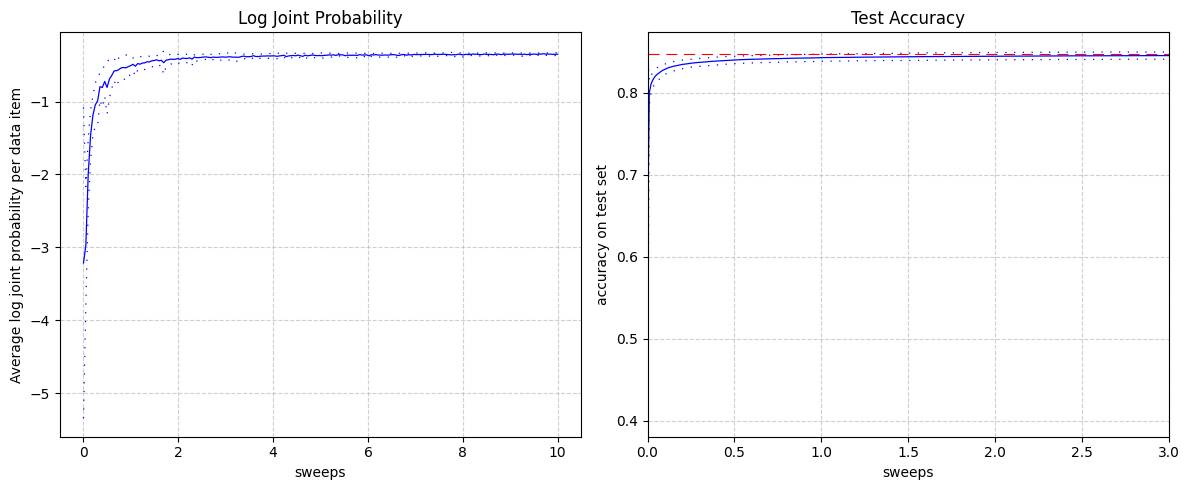

In [15]:
# Calculate Mean and 1 Standard Deviation
mean_lj = np.mean(all_log_joints, axis=0)
std_lj = np.std(all_log_joints, axis=0)

mean_acc = np.mean(all_accuracies, axis=0)
std_acc = np.std(all_accuracies, axis=0)


# Create the x-axis (sweeps)
x_axis_lj = np.linspace(0, sweeps, len(mean_lj))
x_axis_acc = np.linspace(0, sweeps, len(mean_acc))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Left Plot: Log Joint Probability
ax1.plot(x_axis_lj, mean_lj, 'b-', linewidth=0.9, label='Mean')
ax1.plot(x_axis_lj, mean_lj + std_lj, 'b:', linewidth=0.9, dashes=(1,6), label='+1 Std Dev')
ax1.plot(x_axis_lj, mean_lj - std_lj, 'b:', linewidth=0.9, dashes=(1,6), label='-1 Std Dev')
ax1.set_xlabel('sweeps')
ax1.set_ylabel('Average log joint probability per data item')
ax1.set_title('Log Joint Probability')
ax1.grid(True, linestyle='--', alpha=0.6)

# Right Plot: Test Accuracy
ax2.plot(x_axis_acc, mean_acc, 'b-', linewidth=0.9, label='Mean')
ax2.plot(x_axis_acc, mean_acc + std_acc, 'b:', linewidth=0.9, dashes=(1,6), label='+1 Std Dev')
ax2.plot(x_axis_acc, mean_acc - std_acc, 'b:', linewidth=0.9, dashes=(1,6), label='-1 Std Dev')

# final accuracy after 10 sweeps
final_accuracy = mean_acc[-1]
ax2.axhline(y=final_accuracy, color='r', linestyle='--', linewidth=0.8, dashes=(10, 6), label='Acc after 10 sweeps')

ax2.set_xlabel('sweeps')
ax2.set_ylabel('accuracy on test set')
ax2.set_title('Test Accuracy')
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.set_xlim(0, 3)

plt.tight_layout()
plt.show()